# 05 – Visų modelių rezultatų palyginimas – galutinis variantas

Viename Notebook pateikiami **Baseline, MLP, SVR ir CatBoost** rezultatai: DEV rolling-origin palyginimas, TEST rezultatai, bendri metrikų grafikai, faktinė-vs-prognozuota sklaidos grafikai, visas 30 dienų TEST ir paskutinių 5 dienų laiko grafikai, abliacija, atsparumo bandymas bei automatiniai rezultatų paaiškinimai.

**Modelio pasirinkimas grindžiamas DEV rolling-origin rezultatais.

Galutinis TEST naudojamas galutiniam įvertinimui, o ne hiperparametrų parinkimui.**


# 05.

Visų metodų palyginimas

Šis notebook skirtas **vienoje vietoje palyginti Baseline, CatBoost, MLP ir SVR** pagal tas pačias eksperimento sąlygas.

Pagrindinis modelių palyginimas atliekamas **DEV rinkinyje naudojant 3 chronologinius rolling-origin fold'us**.

Galutinis TEST rodomas atskirai kaip galutinis patikrinimas ir **nenaudojamas hiperparametrams parinkti**.

Visoms trims metrikoms **mažesnė reikšmė yra geresnė**.


In [1]:
import warnings, sys, platform
warnings.filterwarnings("ignore")
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.svm import SVR
from catboost import CatBoostRegressor

SEED = 42
np.random.seed(SEED)
DATA_PATH = Path("hour.csv") if Path("hour.csv").exists() else Path("../hour.csv") if Path("../hour.csv").exists() else Path("/mnt/data/hour.csv")
print("Python:", sys.version.split()[0], "| Platform:", platform.platform())
print("Duomenys:", DATA_PATH)


Python: 3.11.9 | Platform: Windows-10-10.0.26200-SP0
Duomenys: hour.csv


## 1.

Duomenų paruošimas – toks pats visiems modeliams


In [2]:
df = pd.read_csv(DATA_PATH)
df["datetime"] = pd.to_datetime(df["dteday"]) + pd.to_timedelta(df["hr"], unit="h")
df = df.sort_values("datetime").drop_duplicates("datetime").reset_index(drop=True)

target_map = df.set_index("datetime")["cnt"]
df["target_time"] = df["datetime"] + pd.Timedelta(hours=1)
df["y"] = df["target_time"].map(target_map)

df["target_hr"] = df["target_time"].dt.hour
df["target_weekday"] = df["target_time"].dt.weekday
df["target_month"] = df["target_time"].dt.month
df["target_hour_sin"] = np.sin(2*np.pi*df["target_hr"]/24)
df["target_hour_cos"] = np.cos(2*np.pi*df["target_hr"]/24)
df["target_dow_sin"] = np.sin(2*np.pi*df["target_weekday"]/7)
df["target_dow_cos"] = np.cos(2*np.pi*df["target_weekday"]/7)
df["target_month_sin"] = np.sin(2*np.pi*(df["target_month"]-1)/12)
df["target_month_cos"] = np.cos(2*np.pi*(df["target_month"]-1)/12)

for h in [0, 23, 167]:
    df[f"cnt_lag_{h}"] = (df["datetime"] - pd.to_timedelta(h, unit="h")).map(target_map)

ts = df.set_index("datetime")["cnt"]
roll24 = ts.rolling("24h", closed="both").mean()
df["cnt_roll24_mean"] = df["datetime"].map(roll24)

prev_day = df["target_time"].map(target_map.shift(freq="24h"))
weekly = [df["target_time"].map(target_map.shift(freq=f"{24*7*w}h")) for w in range(1,5)]
seasonal_mean = pd.concat(weekly, axis=1).mean(axis=1, skipna=True)
df["baseline"] = pd.concat([prev_day.rename("prev_day"), seasonal_mean.rename("seasonal")], axis=1).mean(axis=1, skipna=True)

features = ["season","yr","mnth","holiday","weekday","workingday","weathersit","temp","atemp","hum","windspeed",
            "target_hr","target_weekday","target_month","target_hour_sin","target_hour_cos","target_dow_sin","target_dow_cos",
            "target_month_sin","target_month_cos","cnt_lag_0","cnt_lag_23","cnt_lag_167","cnt_roll24_mean"]
work = df.dropna(subset=["y","baseline"] + features).copy().reset_index(drop=True)
print("Naudojama eilučių:", len(work), "|", work.target_time.min(), "–", work.target_time.max())


Naudojama eilučių: 16897 | 2011-01-08 00:00:00 – 2012-12-31 23:00:00


## 2.

Tas pats chronologinis DEV / TEST ir tie patys 3 rolling-origin fold'ai


In [3]:
TEST_HOURS = 30*24
test_start = work["target_time"].max() - pd.Timedelta(hours=TEST_HOURS-1)
dev = work[work["target_time"] < test_start].copy()
test = work[work["target_time"] >= test_start].copy()

VAL_HOURS = 14*24
folds=[]
for k in [3,2,1]:
    val_end = dev["target_time"].max() - pd.Timedelta(hours=(k-1)*VAL_HOURS)
    val_start = val_end - pd.Timedelta(hours=VAL_HOURS-1)
    tr = dev[dev["target_time"] < val_start]
    va = dev[(dev["target_time"] >= val_start) & (dev["target_time"] <= val_end)]
    folds.append((tr,va))

print("DEV:", dev.target_time.min(), "–", dev.target_time.max(), "N=", len(dev))
print("TEST:", test.target_time.min(), "–", test.target_time.max(), "N=", len(test))
for i,(tr,va) in enumerate(folds,1):
    print(f"Fold {i}: train={len(tr)}, validation={len(va)}, {va.target_time.min()} – {va.target_time.max()}")


DEV: 2011-01-08 00:00:00 – 2012-12-01 23:00:00 N= 16184
TEST: 2012-12-02 00:00:00 – 2012-12-31 23:00:00 N= 713
Fold 1: train=15279, validation=276, 2012-10-21 00:00:00 – 2012-11-03 23:00:00
Fold 2: train=15555, validation=296, 2012-11-04 00:00:00 – 2012-11-17 23:00:00
Fold 3: train=15851, validation=333, 2012-11-18 00:00:00 – 2012-12-01 23:00:00


## 3.

Metrikos ir modeliai


## CatBoost modelio formulės ryšys su kodu

Gradientinio stiprinimo modelio prognozė sudaroma nuosekliai sumuojant silpnųjų modelių indėlį:

\[
\hat{y}(x)=F_0(x)+\sum_{m=1}^{M}\eta h_m(x)
\]

čia \(F_0(x)\) – pradinė prognozė, \(h_m(x)\) – \(m\)-asis sprendimų medis, \(M\) – medžių skaičius, o \(\eta\) – mokymosi žingsnis.

Kode šiuos parametrus atitinka `CatBoostRegressor`: `iterations=500` nusako medžių skaičių, `learning_rate=0.05` – mokymosi žingsnį, o `depth=7` – medžių gylį.


In [4]:
# CatBoost parametrai, naudojami pagrindiniame modelyje:
# iterations = 500      -> M, stiprinimo iteracijų (medžių) skaičius
# learning_rate = 0.05  -> eta, kiekvieno naujo medžio indėlio dydis
# depth = 7             -> sprendimų medžių gylis
#
# Pats modelis kuriamas žemiau esančioje catboost_factory() funkcijoje
# ir ta pati funkcija naudojama rolling-origin, TEST bei abliacijos eksperimentuose.


In [5]:
def metrics(y, pred, peak_threshold):
    y=np.asarray(y); pred=np.asarray(pred)
    peak=y > peak_threshold
    return {
        "MAE": mean_absolute_error(y,pred),
        "RMSE": mean_squared_error(y,pred)**0.5,
        "Peak_under_rate": np.mean(pred[peak] < y[peak]) if peak.sum() else np.nan
    }

def catboost_factory():
    return CatBoostRegressor(iterations=500, depth=7, learning_rate=0.05, loss_function="RMSE", random_seed=SEED, verbose=False, allow_writing_files=False)

def mlp_factory():
    return Pipeline([("imp",SimpleImputer(strategy="median")),("scale",StandardScaler()),
                     ("model",MLPRegressor(hidden_layer_sizes=(32,16),activation="relu",max_iter=80,early_stopping=True,random_state=SEED))])

def svr_factory():
    return Pipeline([("imp",SimpleImputer(strategy="median")),("scale",StandardScaler()),
                     ("model",SVR(kernel="rbf", C=100, epsilon=0.1, gamma="scale"))])

models = {"CatBoost":catboost_factory, "MLP":mlp_factory, "SVR":svr_factory}


## 4.

Bendras rolling-origin palyginimas DEV rinkinyje


In [6]:
rows=[]
fold_predictions={name:[] for name in models}

for i,(tr,va) in enumerate(folds,1):
    q90=tr["y"].quantile(.90)
    b=metrics(va["y"], va["baseline"], q90)
    b.update({"Model":"Baseline","Fold":i})
    rows.append(b)
    for name,factory in models.items():
        model=factory(); model.fit(tr[features],tr["y"])
        pred=np.maximum(0,model.predict(va[features]))
        m=metrics(va["y"],pred,q90); m.update({"Model":name,"Fold":i})
        rows.append(m)

cv_results=pd.DataFrame(rows)
cv_summary=cv_results.groupby("Model")[["MAE","RMSE","Peak_under_rate"]].mean()
cv_summary=cv_summary.loc[["Baseline","CatBoost","MLP","SVR"]]
print("ROLLING-ORIGIN DEV VIDURKIAI (mažiau = geriau):")
display(cv_summary.round(3))


ROLLING-ORIGIN DEV VIDURKIAI (mažiau = geriau):


,MAE,RMSE,Peak_under_rate
Model,,,
Baseline,54.299,87.825,0.661
CatBoost,24.341,36.543,0.581
MLP,38.865,57.314,0.681
SVR,33.565,50.454,0.726


### Rezultatų lentelės paaiškinimas

Visoms trims metrikoms mažesnė reikšmė reiškia geresnį rezultatą.

DEV dalis naudojama pagrindiniam metodų palyginimui, todėl galutinis TEST nėra naudojamas modelio pasirinkimui.


In [7]:
print("REZULTATŲ PAAIŠKINIMAS")
print("-"*70)

best_mae = cv_summary["MAE"].idxmin()
best_rmse = cv_summary["RMSE"].idxmin()
best_peak = cv_summary["Peak_under_rate"].idxmin()

print(f"Pagal MAE geriausias rezultatas: {best_mae} ({cv_summary.loc[best_mae,'MAE']:.3f}).")
print(f"Pagal RMSE geriausias rezultatas: {best_rmse} ({cv_summary.loc[best_rmse,'RMSE']:.3f}).")
print(f"Pagal piko neįvertinimo dažnį geriausias rezultatas: {best_peak} "
      f"({cv_summary.loc[best_peak,'Peak_under_rate']:.3f}).")

base_mae = cv_summary.loc["Baseline","MAE"]
base_rmse = cv_summary.loc["Baseline","RMSE"]

if best_mae != "Baseline":
    imp_mae = (base_mae - cv_summary.loc[best_mae,"MAE"]) / base_mae * 100
    print(f"{best_mae} MAE yra apie {imp_mae:.1f}% mažesnė už Baseline.")

if best_rmse != "Baseline":
    imp_rmse = (base_rmse - cv_summary.loc[best_rmse,"RMSE"]) / base_rmse * 100
    print(f"{best_rmse} RMSE yra apie {imp_rmse:.1f}% mažesnė už Baseline.")

print("\nIšvada: ši lentelė leidžia palyginti visus metodus tomis pačiomis "
      "chronologinėmis sąlygomis. Modelio pasirinkimas turi būti grindžiamas DEV, o ne galutiniu TEST.")


REZULTATŲ PAAIŠKINIMAS
----------------------------------------------------------------------
Pagal MAE geriausias rezultatas: CatBoost (24.341).
Pagal RMSE geriausias rezultatas: CatBoost (36.543).
Pagal piko neįvertinimo dažnį geriausias rezultatas: CatBoost (0.581).
CatBoost MAE yra apie 55.2% mažesnė už Baseline.
CatBoost RMSE yra apie 58.4% mažesnė už Baseline.

Išvada: ši lentelė leidžia palyginti visus metodus tomis pačiomis chronologinėmis sąlygomis. Modelio pasirinkimas turi būti grindžiamas DEV, o ne galutiniu TEST.


## 5.

DEV rezultatų grafikai – visi metodai viename vaizde


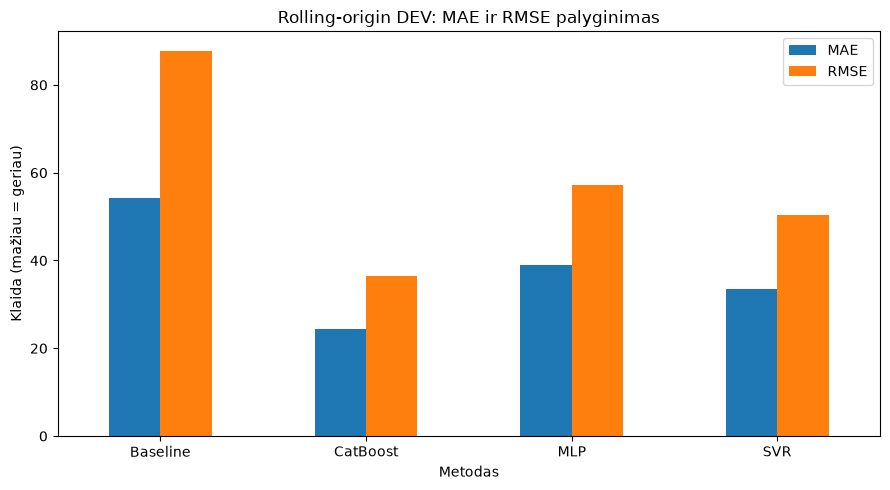

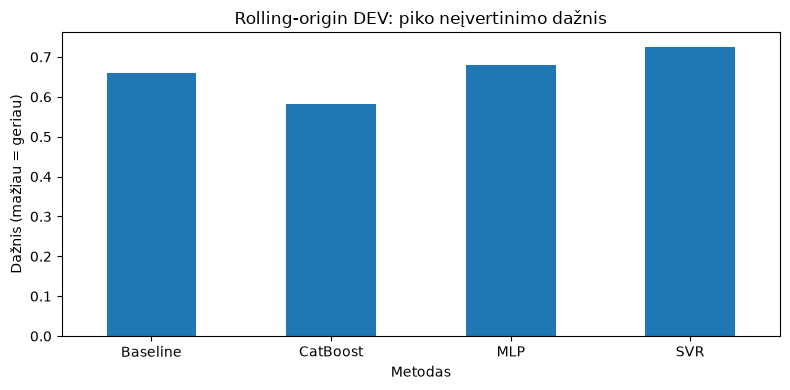

In [8]:
ax=cv_summary[["MAE","RMSE"]].plot(kind="bar", figsize=(9,5))
ax.set_title("Rolling-origin DEV: MAE ir RMSE palyginimas")
ax.set_ylabel("Klaida (mažiau = geriau)")
ax.set_xlabel("Metodas")
plt.xticks(rotation=0)
plt.tight_layout(); plt.show()

ax=cv_summary["Peak_under_rate"].plot(kind="bar", figsize=(8,4))
ax.set_title("Rolling-origin DEV: piko neįvertinimo dažnis")
ax.set_ylabel("Dažnis (mažiau = geriau)")
ax.set_xlabel("Metodas")
plt.xticks(rotation=0)
plt.tight_layout(); plt.show()


### MAE ir RMSE grafiko paaiškinimas

Šiame grafike vienu metu lyginamos visų metodų **MAE** ir **RMSE** paklaidos.

Kuo stulpelis žemesnis, tuo prognozės klaida mažesnė.

MAE parodo vidutinę absoliučią klaidą, o RMSE stipriau išryškina dideles prognozavimo klaidas.


In [9]:
mae_order = cv_summary["MAE"].sort_values()
rmse_order = cv_summary["RMSE"].sort_values()

print("MAE – nuo mažiausios klaidos iki didžiausios:")
for n, v in mae_order.items():
    print(f"  {n}: {v:.3f}")

print("\nRMSE – nuo mažiausios klaidos iki didžiausios:")
for n, v in rmse_order.items():
    print(f"  {n}: {v:.3f}")

print(f"\nPagal MAE mažiausią klaidą turi {mae_order.index[0]}.")
print(f"Pagal RMSE mažiausią klaidą turi {rmse_order.index[0]}.")


MAE – nuo mažiausios klaidos iki didžiausios:
  CatBoost: 24.341
  SVR: 33.565
  MLP: 38.865
  Baseline: 54.299

RMSE – nuo mažiausios klaidos iki didžiausios:
  CatBoost: 36.543
  SVR: 50.454
  MLP: 57.314
  Baseline: 87.825

Pagal MAE mažiausią klaidą turi CatBoost.
Pagal RMSE mažiausią klaidą turi CatBoost.


## 6.

Galutinis TEST – visi modeliai vienodomis sąlygomis


In [10]:
q90_dev = dev["y"].quantile(.90)
test_rows = []
preds = {}
fitted_models = {}

b = metrics(test["y"], test["baseline"], q90_dev)
b["Model"] = "Baseline"
test_rows.append(b)

for name, factory in models.items():
    model = factory()
    model.fit(dev[features], dev["y"])
    pred = np.maximum(0, model.predict(test[features]))
    fitted_models[name] = model
    preds[name] = pred

    m = metrics(test["y"], pred, q90_dev)
    m["Model"] = name
    test_rows.append(m)

test_summary = (
    pd.DataFrame(test_rows)
    .set_index("Model")
    .loc[["Baseline", "CatBoost", "MLP", "SVR"]]
)

print("GALUTINIS TEST (mažiau = geriau):")
display(test_summary.round(3))


GALUTINIS TEST (mažiau = geriau):


,MAE,RMSE,Peak_under_rate
Model,,,
Baseline,51.302,81.164,0.78
CatBoost,20.523,31.373,0.70
MLP,29.387,44.141,0.66
SVR,25.393,40.071,0.74


### Galutinio TEST lentelės paaiškinimas

TEST yra paskutinės, anksčiau modelių nematytos dienos.

Ši lentelė parodo, kaip jau paruošti modeliai veikia galutiniame laikotarpyje.

**TEST rezultatai naudojami galutiniam įvertinimui, o ne hiperparametrų parinkimui ar modelio pasirinkimui.**


In [11]:
print("GALUTINIO TEST REZULTATŲ PAAIŠKINIMAS")
print("-"*70)
for metric, label in [
    ("MAE","MAE"),
    ("RMSE","RMSE"),
    ("Peak_under_rate","piko neįvertinimo dažnį")
]:
    n = test_summary[metric].idxmin()
    v = test_summary.loc[n, metric]
    print(f"Mažiausią {label} TEST rinkinyje gavo {n}: {v:.3f}.")

print("\nSvarbu: šie TEST rezultatai tik parodo galutinį veikimą. "
      "Pagrindinis metodų pasirinkimas buvo atliekamas pagal DEV rolling-origin rezultatus.")


GALUTINIO TEST REZULTATŲ PAAIŠKINIMAS
----------------------------------------------------------------------
Mažiausią MAE TEST rinkinyje gavo CatBoost: 20.523.
Mažiausią RMSE TEST rinkinyje gavo CatBoost: 31.373.
Mažiausią piko neįvertinimo dažnį TEST rinkinyje gavo MLP: 0.660.

Svarbu: šie TEST rezultatai tik parodo galutinį veikimą. Pagrindinis metodų pasirinkimas buvo atliekamas pagal DEV rolling-origin rezultatus.


## 7.

TEST metrikų grafikai


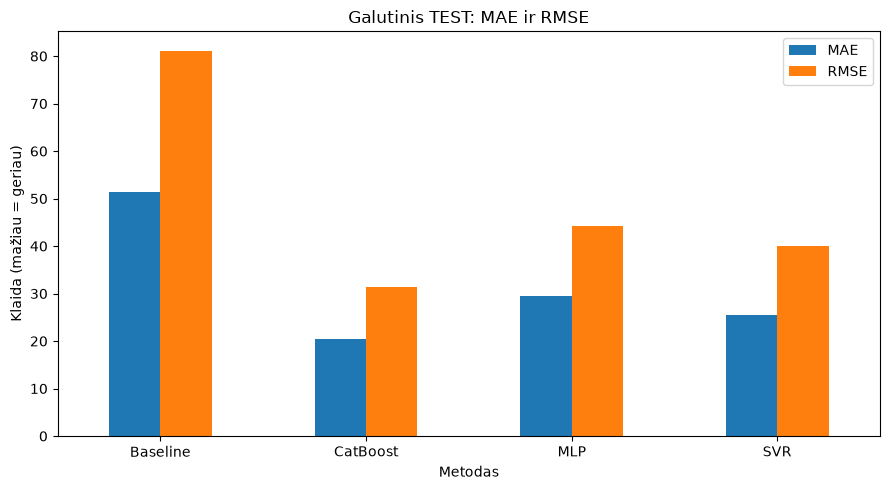

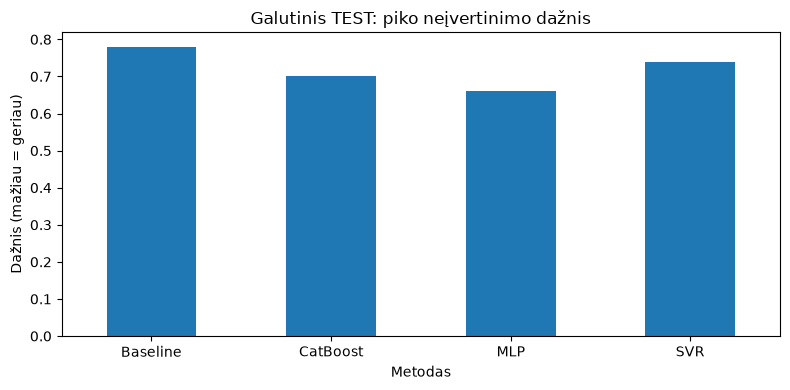

In [12]:
ax=test_summary[["MAE","RMSE"]].plot(kind="bar", figsize=(9,5))
ax.set_title("Galutinis TEST: MAE ir RMSE")
ax.set_ylabel("Klaida (mažiau = geriau)")
ax.set_xlabel("Metodas")
plt.xticks(rotation=0)
plt.tight_layout(); plt.show()

ax=test_summary["Peak_under_rate"].plot(kind="bar", figsize=(8,4))
ax.set_title("Galutinis TEST: piko neįvertinimo dažnis")
ax.set_ylabel("Dažnis (mažiau = geriau)")
ax.set_xlabel("Metodas")
plt.xticks(rotation=0)
plt.tight_layout(); plt.show()


### TEST metrikų grafikų paaiškinimas

Grafikai leidžia vizualiai patikrinti, ar DEV dalyje matytos tendencijos išlieka ir galutiniame TEST laikotarpyje.

Mažesni MAE, RMSE ir piko neįvertinimo stulpeliai reiškia mažesnę klaidą.

Jei vienas modelis geriausias pagal MAE, bet kitas – pagal pikus, tai reikia paminėti kaip skirtingą modelių elgesį.


In [13]:
print("TEST GRAFIKŲ SANTRAUKA")
print("-"*70)
print(f"Mažiausia MAE: {test_summary['MAE'].idxmin()} "
      f"({test_summary['MAE'].min():.3f})")
print(f"Mažiausia RMSE: {test_summary['RMSE'].idxmin()} "
      f"({test_summary['RMSE'].min():.3f})")
print(f"Mažiausias piko neįvertinimas: {test_summary['Peak_under_rate'].idxmin()} "
      f"({test_summary['Peak_under_rate'].min():.3f})")


TEST GRAFIKŲ SANTRAUKA
----------------------------------------------------------------------
Mažiausia MAE: CatBoost (20.523)
Mažiausia RMSE: CatBoost (31.373)
Mažiausias piko neįvertinimas: MLP (0.660)


## 8.

Faktinė paklausa ir VISŲ modelių prognozės tame pačiame grafike


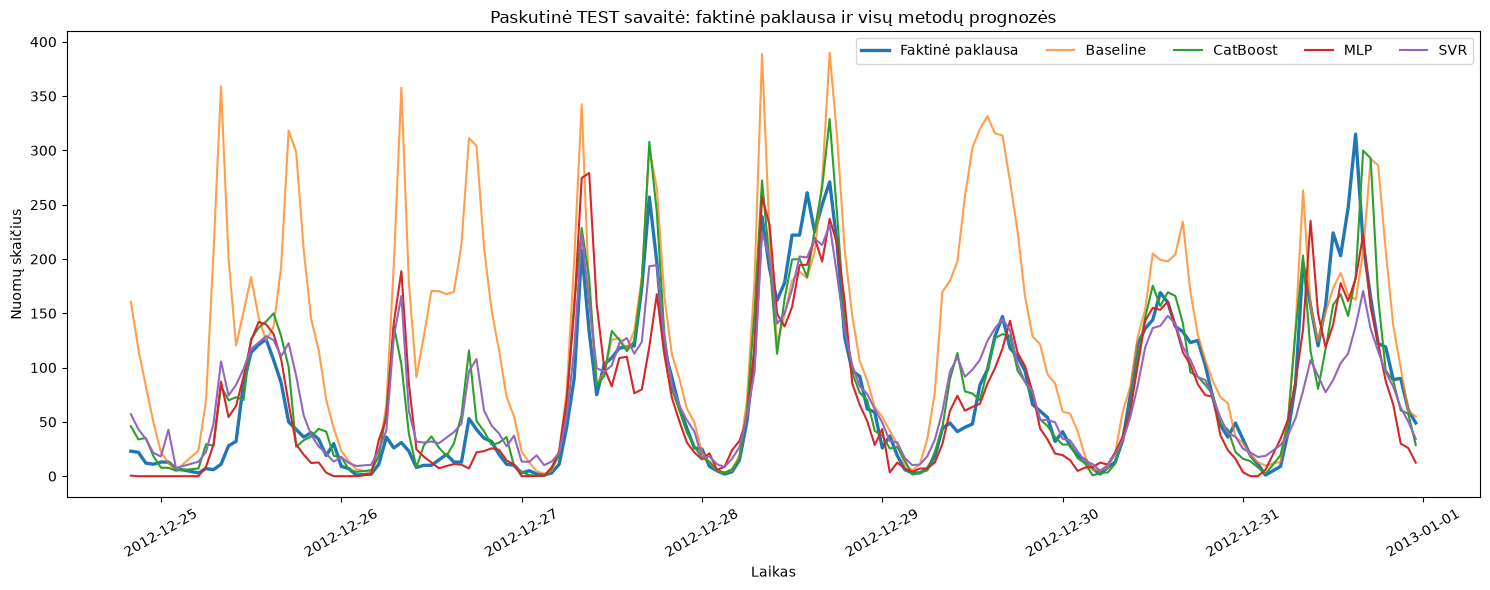

In [14]:
plot_df=test[["target_time","y","baseline"]].copy()
for name,pred in preds.items(): plot_df[name]=pred
show=plot_df.tail(7*24)
plt.figure(figsize=(15,6))
plt.plot(show.target_time,show.y,label="Faktinė paklausa",linewidth=2.4)
plt.plot(show.target_time,show.baseline,label="Baseline",alpha=.75)
plt.plot(show.target_time,show.CatBoost,label="CatBoost")
plt.plot(show.target_time,show.MLP,label="MLP")
plt.plot(show.target_time,show.SVR,label="SVR")
plt.title("Paskutinė TEST savaitė: faktinė paklausa ir visų metodų prognozės")
plt.xlabel("Laikas"); plt.ylabel("Nuomų skaičius")
plt.legend(ncol=5); plt.xticks(rotation=30); plt.tight_layout(); plt.show()


### Faktinės ir prognozuotos paklausos grafiko paaiškinimas

Juoda / pagrindinė faktinės paklausos kreivė rodo tikrą nuomų skaičių, o kitos kreivės – Baseline, CatBoost, MLP ir SVR prognozes.

Geresnio modelio prognozės kreivė turėtų kuo tiksliau sekti faktinės paklausos kilimus ir kritimus.

Ypač svarbu stebėti didelės paklausos pikus: jei prognozės linija juose nuolat lieka žemiau faktinės, modelis linkęs paklausą neįvertinti.


In [15]:
print("-"*70)
print("1. Žiūrėkite, kurios prognozės kreivė dažniausiai yra arčiausiai faktinės paklausos.")
print("2. Patikrinkite, kaip modeliai atkuria staigius paklausos pakilimus ir kritimus.")
print("3. Jei prognozė piko metu nuolat yra žemiau faktinės reikšmės, modelis pikus neįvertina.")
print("4. Vizualų įspūdį visada vertinkite kartu su MAE, RMSE ir Peak_under_rate metrikomis.")


----------------------------------------------------------------------
1. Žiūrėkite, kurios prognozės kreivė dažniausiai yra arčiausiai faktinės paklausos.
2. Patikrinkite, kaip modeliai atkuria staigius paklausos pakilimus ir kritimus.
3. Jei prognozė piko metu nuolat yra žemiau faktinės reikšmės, modelis pikus neįvertina.
4. Vizualų įspūdį visada vertinkite kartu su MAE, RMSE ir Peak_under_rate metrikomis.


## 9.

Aiški rezultatų išvada


In [16]:
def best(metric, table):
    return table[metric].idxmin(), table[metric].min()

print("PAGRINDINIS PALYGINIMAS – DEV rolling-origin:")
for metric in ["MAE","RMSE","Peak_under_rate"]:
    name,val=best(metric,cv_summary)
    print(f"• Mažiausia {metric}: {name} = {val:.3f}")

print("\nGALUTINIS TEST:")
for metric in ["MAE","RMSE","Peak_under_rate"]:
    name,val=best(metric,test_summary)
    print(f"• Mažiausia {metric}: {name} = {val:.3f}")

print("\nInterpretacija:")
print("Modelių pasirinkimas turi būti grindžiamas DEV rolling-origin rezultatais, nes TEST nenaudojamas modelio ar hiperparametrų parinkimui.")
print("TEST rezultatai naudojami tik galutiniam jau fiksuotų modelių patikrinimui.")


PAGRINDINIS PALYGINIMAS – DEV rolling-origin:
• Mažiausia MAE: CatBoost = 24.341
• Mažiausia RMSE: CatBoost = 36.543
• Mažiausia Peak_under_rate: CatBoost = 0.581

GALUTINIS TEST:
• Mažiausia MAE: CatBoost = 20.523
• Mažiausia RMSE: CatBoost = 31.373
• Mažiausia Peak_under_rate: MLP = 0.660

Interpretacija:
Modelių pasirinkimas turi būti grindžiamas DEV rolling-origin rezultatais, nes TEST nenaudojamas modelio ar hiperparametrų parinkimui.
TEST rezultatai naudojami tik galutiniam jau fiksuotų modelių patikrinimui.


## Faktinė ir prognozuota paklausa – visų metodų palyginimas (TEST)

Grafikuose palyginamos faktinės ir kiekvieno metodo prognozuotos reikšmės.

Punktyrinė įstrižainė yra ideali prognozė (`ŷ = y`).

Kuo taškai arčiau jos, tuo prognozė tikslesnė.

Taškai žemiau linijos reiškia paklausos **neįvertinimą**, o taškai virš linijos – **pervertinimą**.


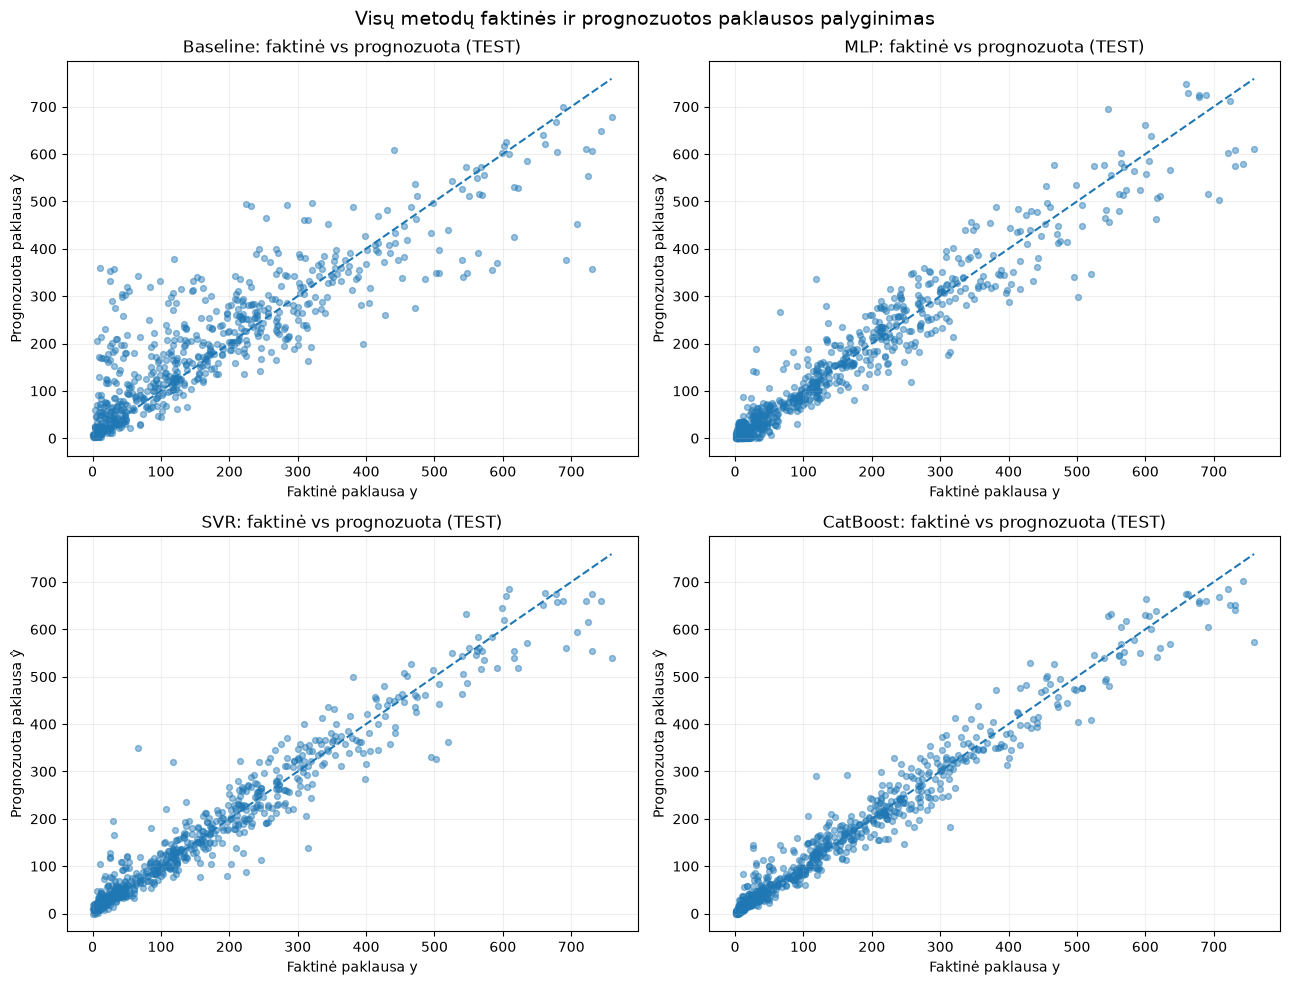

In [17]:
# Faktinė vs. prognozuota: Baseline, MLP, SVR ir CatBoost

y_true_sc = test["y"].to_numpy()

pred_map = {
    "Baseline": test["baseline"].to_numpy(),
    "MLP": np.asarray(preds["MLP"]),
    "SVR": np.asarray(preds["SVR"]),
    "CatBoost": np.asarray(preds["CatBoost"])
}

required = ["Baseline", "MLP", "SVR", "CatBoost"]

mn = min(
    float(np.nanmin(y_true_sc)),
    *(float(np.nanmin(pred_map[m])) for m in required)
)
mx = max(
    float(np.nanmax(y_true_sc)),
    *(float(np.nanmax(pred_map[m])) for m in required)
)

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes = axes.ravel()

for ax, name in zip(axes, required):
    yp = pred_map[name]
    ax.scatter(y_true_sc, yp, alpha=0.45, s=18)
    ax.plot([mn, mx], [mn, mx], "--", linewidth=1.5)
    ax.set_title(f"{name}: faktinė vs prognozuota (TEST)")
    ax.set_xlabel("Faktinė paklausa y")
    ax.set_ylabel("Prognozuota paklausa ŷ")
    ax.grid(alpha=0.2)

plt.suptitle("Visų metodų faktinės ir prognozuotos paklausos palyginimas", fontsize=14)
plt.tight_layout()
plt.show()


### Grafikų paaiškinimas

Visiems keturiems metodams naudojama ta pati TEST imtis, todėl grafikus galima tiesiogiai lyginti.

Geresnio modelio taškai turėtų būti labiau susitelkę aplink punktyrinę įstrižainę.

Ypač svarbi viršutinė grafikų dalis, kur yra didelės paklausos valandos: jei ten daug taškų yra žemiau įstrižainės, modelis linkęs nepakankamai įvertinti paklausos pikus.

Grafikai vertinami kartu su **MAE, RMSE ir Peak underestimation rate** metrikomis.


In [18]:
print("FAKTINĖS IR PROGNOZUOTOS PAKLAUSOS GRAFIKŲ SANTRAUKA")
print("-"*70)
print("• Kuo taškai arčiau punktyrinės y = ŷ linijos, tuo prognozė tikslesnė.")
print("• Taškai žemiau linijos reiškia paklausos neįvertinimą.")
print("• Taškai virš linijos reiškia paklausos pervertinimą.")
print("• Galutinė išvada daroma kartu su MAE, RMSE ir piko neįvertinimo metrika.")


FAKTINĖS IR PROGNOZUOTOS PAKLAUSOS GRAFIKŲ SANTRAUKA
----------------------------------------------------------------------
• Kuo taškai arčiau punktyrinės y = ŷ linijos, tuo prognozė tikslesnė.
• Taškai žemiau linijos reiškia paklausos neįvertinimą.
• Taškai virš linijos reiškia paklausos pervertinimą.
• Galutinė išvada daroma kartu su MAE, RMSE ir piko neįvertinimo metrika.


## Prognozių palyginimas laike – visas TEST ir paskutinės 5 dienos

Grafike pateikiama **faktinė dviračių paklausa**, **Baseline**, **MLP**, **SVR** ir **CatBoost** prognozės.

Viršutinis grafikas rodo visą galutinį **30 dienų TEST laikotarpį**, todėl galima įvertinti bendrą modelių elgesį.

Apatinis grafikas rodo tik **paskutines 5 dienas**, kad būtų lengviau pamatyti konkrečius paklausos pakilimus, kritimus ir modelių skirtumus.

Kuo modelio prognozės linija arčiau faktinės `cnt` linijos, tuo prognozė tikslesnė.


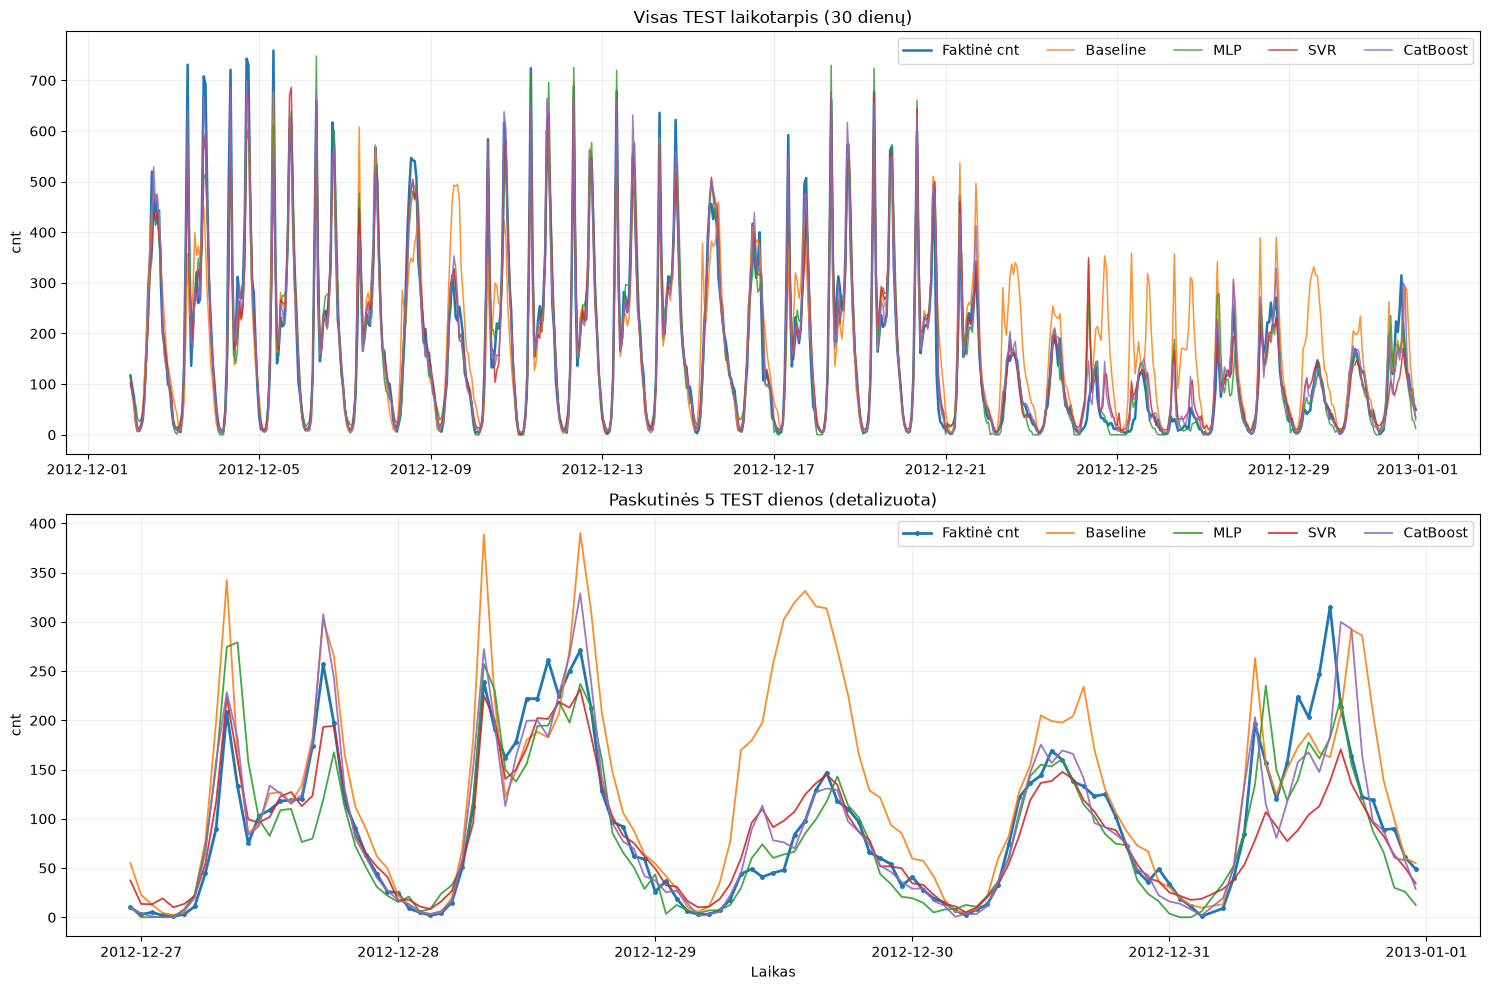

In [19]:
# Visas TEST laikotarpis ir paskutinės 5 dienos

dt_plot = pd.to_datetime(test["target_time"]).reset_index(drop=True)
y_plot = test["y"].to_numpy()

preds_time = {
    "Baseline": test["baseline"].to_numpy(),
    "MLP": np.asarray(preds["MLP"]),
    "SVR": np.asarray(preds["SVR"]),
    "CatBoost": np.asarray(preds["CatBoost"])
}

fig, axes = plt.subplots(2, 1, figsize=(15, 10))

# Visas 30 dienų TEST laikotarpis
axes[0].plot(dt_plot, y_plot, label="Faktinė cnt", linewidth=1.8)
for name in ["Baseline", "MLP", "SVR", "CatBoost"]:
    axes[0].plot(dt_plot, preds_time[name], label=name, linewidth=1.1, alpha=0.85)

axes[0].set_title("Visas TEST laikotarpis (30 dienų)")
axes[0].set_ylabel("cnt")
axes[0].legend(ncol=5)
axes[0].grid(alpha=0.2)

# Paskutinės 5 dienos
start_time = dt_plot.iloc[-1] - pd.Timedelta(days=5)
start = np.where(dt_plot >= start_time)[0][0]

axes[1].plot(dt_plot.iloc[start:], y_plot[start:], label="Faktinė cnt",
             linewidth=2.0, marker="o", markersize=2.5)

for name in ["Baseline", "MLP", "SVR", "CatBoost"]:
    axes[1].plot(dt_plot.iloc[start:], preds_time[name][start:],
                 label=name, linewidth=1.3, alpha=0.9)

axes[1].set_title("Paskutinės 5 TEST dienos (detalizuota)")
axes[1].set_ylabel("cnt")
axes[1].set_xlabel("Laikas")
axes[1].legend(ncol=5)
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()


### Laiko grafikų paaiškinimas

**Viršutinis grafikas** parodo, kaip modeliai prognozuoja paklausą per visą 30 dienų TEST laikotarpį.

Jame galima įvertinti, ar modeliai seka bendrą paklausos kitimo tendenciją ir kasdienius pikus.

**Apatinis grafikas** priartina paskutines 5 dienas.

Čia lengviau pastebėti, kuris modelis tiksliau atkuria konkrečius paklausos pakilimus ir kritimus.

Jeigu modelio linija piko metu yra **žemiau faktinės paklausos**, modelis paklausą neįvertino.

Jeigu linija yra **aukščiau**, modelis paklausą pervertino.

Šis grafikas yra vizualus palyginimas, todėl galutinės išvados daromos kartu su **MAE, RMSE ir Peak underestimation rate** metrikomis.


In [20]:
# Automatinė trumpoji šių grafikų santrauka pagal TEST metrikas

print("PROGNOZIŲ LAIKE PAAIŠKINIMAS")
print("-"*70)

if "test_summary" in globals():
    best_mae_t = test_summary["MAE"].idxmin()
    best_rmse_t = test_summary["RMSE"].idxmin()
    best_peak_t = test_summary["Peak_under_rate"].idxmin()

    print(f"Mažiausią TEST MAE turi {best_mae_t}: {test_summary.loc[best_mae_t,'MAE']:.3f}.")
    print(f"Mažiausią TEST RMSE turi {best_rmse_t}: {test_summary.loc[best_rmse_t,'RMSE']:.3f}.")
    print(f"Mažiausią TEST piko neįvertinimo dažnį turi {best_peak_t}: "
          f"{test_summary.loc[best_peak_t,'Peak_under_rate']:.3f}.")
    print("\nGrafikuose tai galima vizualiai palyginti pagal tai, "
          "kaip arti faktinės cnt kreivės eina kiekvieno modelio prognozė.")
else:
    print("Grafike palyginamos faktinė paklausa, Baseline, MLP, SVR ir CatBoost.")
    print("Skaitinę išvadą vertinkite kartu su aukščiau pateikta TEST rezultatų lentele.")


PROGNOZIŲ LAIKE PAAIŠKINIMAS
----------------------------------------------------------------------
Mažiausią TEST MAE turi CatBoost: 20.523.
Mažiausią TEST RMSE turi CatBoost: 31.373.
Mažiausią TEST piko neįvertinimo dažnį turi MLP: 0.660.

Grafikuose tai galima vizualiai palyginti pagal tai, kaip arti faktinės cnt kreivės eina kiekvieno modelio prognozė.


## Didžiausių prognozavimo klaidų analizė

Atrenkama 10 TEST laikotarpio atvejų, kuriuose **CatBoost** absoliuti prognozavimo klaida buvo didžiausia.

Absoliuti klaida apskaičiuojama:

\[
e_i = |y_i - \hat{y}_i|
\]

čia \(y_i\) – faktinė dviračių paklausa, o \(\hat{y}_i\) – CatBoost prognozuota paklausa.

Papildomai nurodoma klaidos kryptis:
- **neįvertino** – prognozė mažesnė už faktinę paklausą;
- **pervertino** – prognozė didesnė už faktinę paklausą.


In [21]:
# Sudarome CatBoost TEST prognozių klaidų lentelę.
# Naudojamos jau anksčiau apskaičiuotos TEST prognozės, todėl modelis čia iš naujo nemokomas.

error_examples = pd.DataFrame({
    "Laikas": pd.to_datetime(test["target_time"]).to_numpy(),
    "Faktinė_cnt": test["y"].to_numpy(),
    "CatBoost_prognozė": np.asarray(preds["CatBoost"])
})

# Absoliuti klaida parodo prognozės nuokrypio dydį nepriklausomai nuo krypties.
error_examples["Absoliuti_klaida"] = np.abs(
    error_examples["Faktinė_cnt"] - error_examples["CatBoost_prognozė"]
)

# Klaidos kryptis leidžia atskirti paklausos neįvertinimą nuo pervertinimo.
error_examples["Klaidos_kryptis"] = np.where(
    error_examples["CatBoost_prognozė"] < error_examples["Faktinė_cnt"],
    "Neįvertino",
    np.where(
        error_examples["CatBoost_prognozė"] > error_examples["Faktinė_cnt"],
        "Pervertino",
        "Tiksli prognozė"
    )
)

# Atrenkame 10 didžiausių absoliučių klaidų.
top10_errors = (
    error_examples
    .sort_values("Absoliuti_klaida", ascending=False)
    .head(10)
    .reset_index(drop=True)
)

display(
    top10_errors.style.format({
        "Faktinė_cnt": "{:.0f}",
        "CatBoost_prognozė": "{:.1f}",
        "Absoliuti_klaida": "{:.1f}"
    })
)

# Trumpa skaitinė santrauka.
n_under = (top10_errors["Klaidos_kryptis"] == "Neįvertino").sum()
n_over = (top10_errors["Klaidos_kryptis"] == "Pervertino").sum()

print(f"Iš 10 didžiausių klaidų: {n_under} – paklausos neįvertinimai, "
      f"{n_over} – paklausos pervertinimai.")
print(f"Didžiausia absoliuti klaida: {top10_errors['Absoliuti_klaida'].max():.1f}.")


,Laikas,Faktinė_cnt,CatBoost_prognozė,Absoliuti_klaida,Klaidos_kryptis
0,2012-12-05 08:00:00,759,573.8,185.2,Neįvertino
1,2012-12-20 19:00:00,118,291.3,173.3,Pervertino
2,2012-12-31 15:00:00,315,183.6,131.4,Neįvertino
3,2012-12-31 17:00:00,164,292.7,128.7,Pervertino
4,2012-12-24 17:00:00,26,145.0,119.0,Pervertino
5,2012-12-26 07:00:00,26,138.5,112.5,Pervertino
6,2012-12-02 12:00:00,520,407.9,112.1,Neįvertino
7,2012-12-16 18:00:00,107,206.8,99.8,Pervertino
8,2012-12-31 14:00:00,247,147.5,99.5,Neįvertino
9,2012-12-02 13:00:00,431,529.0,98.0,Pervertino


Iš 10 didžiausių klaidų: 4 – paklausos neįvertinimai, 6 – paklausos pervertinimai.
Didžiausia absoliuti klaida: 185.2.


Didžiausių klaidų lentelė parodo konkrečius laikotarpius, kuriuose CatBoost prognozė labiausiai skyrėsi nuo faktinės paklausos. Ši analizė papildo bendras MAE ir RMSE metrikas, nes leidžia įvertinti ne tik vidutinį tikslumą, bet ir pavienius didelius nuokrypius.


## Abliacijos eksperimentas – CatBoost su ir be ankstesnės paklausos požymių

Šiame eksperimente tikrinama, kiek pagrindiniam **CatBoost** modeliui naudingi ankstesnės paklausos požymiai (`lag` ir `rolling`).

Abu variantai vertinami **DEV rolling-origin** dalyje tais pačiais fold'ais.

Galutinis TEST šiame eksperimente nenaudojamas.

- **Su lag/rolling** – naudojami visi modelio požymiai.

- **Be lag/rolling** – pašalinami ankstesnės paklausos `lag` ir slenkamojo vidurkio požymiai.

Jeigu pašalinus šiuos požymius MAE ir RMSE padidėja, tai rodo, kad ankstesnės paklausos informacija modeliui yra naudinga.


Pašalinami istorijos požymiai: ['cnt_lag_0', 'cnt_lag_23', 'cnt_lag_167', 'cnt_roll24_mean']


,MAE,RMSE,Peak_under_rate
Variantas,,,
Su lag/rolling požymiais,24.341,36.543,0.581
Be lag/rolling požymių,38.843,59.725,0.578


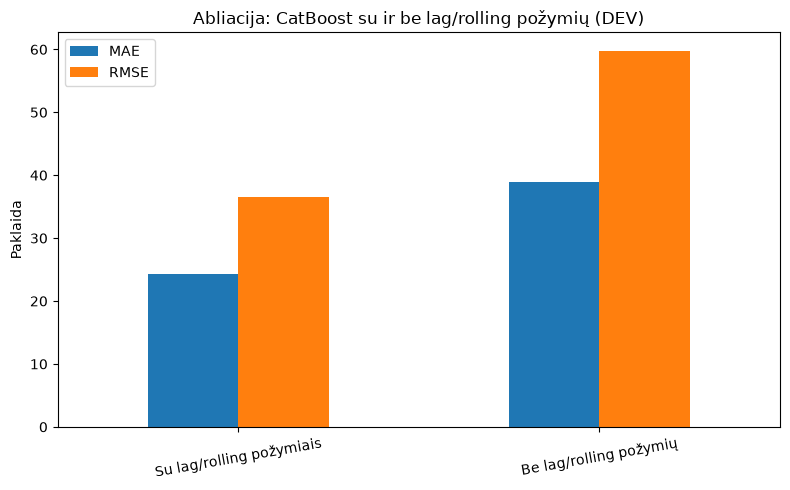

CatBoost su lag/rolling požymiais: MAE = 24.341
CatBoost be lag/rolling požymių: MAE = 38.843
MAE pokytis pašalinus istorijos požymius: +59.6%


In [22]:
# ABLACIJA: CatBoost su / be lag ir rolling požymių (DEV rolling-origin)

features_full_ab = list(features)

history_features_ab = [
    c for c in features_full_ab
    if ("lag" in c.lower()) or ("roll" in c.lower()) or c.lower().startswith("cnt_")
]
features_no_history_ab = [c for c in features_full_ab if c not in history_features_ab]

print("Pašalinami istorijos požymiai:", history_features_ab)

ab_rows = []

for variant, feats in [
    ("Su lag/rolling požymiais", features_full_ab),
    ("Be lag/rolling požymių", features_no_history_ab),
]:
    fold_scores = []

    for fold_no, (tr, va) in enumerate(folds, 1):
        q90 = tr["y"].quantile(.90)

        model_ab = catboost_factory()
        model_ab.fit(tr[feats], tr["y"])
        pred_ab = np.maximum(0, model_ab.predict(va[feats]))

        score = metrics(va["y"], pred_ab, q90)
        fold_scores.append(score)

    fold_df = pd.DataFrame(fold_scores)
    ab_rows.append({
        "Variantas": variant,
        "MAE": fold_df["MAE"].mean(),
        "RMSE": fold_df["RMSE"].mean(),
        "Peak_under_rate": fold_df["Peak_under_rate"].mean()
    })

ablation_summary = pd.DataFrame(ab_rows).set_index("Variantas")
display(ablation_summary.round(3))

ax = ablation_summary[["MAE", "RMSE"]].plot(
    kind="bar", figsize=(8, 5), rot=10,
    title="Abliacija: CatBoost su ir be lag/rolling požymių (DEV)"
)
ax.set_ylabel("Paklaida")
ax.set_xlabel("")
plt.tight_layout()
plt.show()

full_mae = ablation_summary.loc["Su lag/rolling požymiais", "MAE"]
nohist_mae = ablation_summary.loc["Be lag/rolling požymių", "MAE"]
change = (nohist_mae - full_mae) / full_mae * 100

print(f"CatBoost su lag/rolling požymiais: MAE = {full_mae:.3f}")
print(f"CatBoost be lag/rolling požymių: MAE = {nohist_mae:.3f}")
print(f"MAE pokytis pašalinus istorijos požymius: {change:+.1f}%")


## Atsparumo bandymas – meteorologinių požymių triukšmas

Šiuo bandymu tikrinama, kaip modelių rezultatai keičiasi, kai meteorologiniai požymiai nėra visiškai tikslūs.

Tai imituoja realią situaciją, kai kitos valandos orų informacija gali turėti prognozės paklaidą.

Kiekvienam modeliui palyginama:

- **švari įvestis**;

- **įvestis su meteorologinių požymių triukšmu**.

Kuo mažiau padidėja MAE, tuo modelis atsparesnis meteorologinių duomenų netikslumui.


,MAE_švari,MAE_su_triukšmu,MAE_pokytis_%
Modelis,,,
Baseline,51.302,51.302,0.000
MLP,29.387,29.563,0.599
SVR,25.393,26.166,3.043
CatBoost,20.523,20.365,-0.772


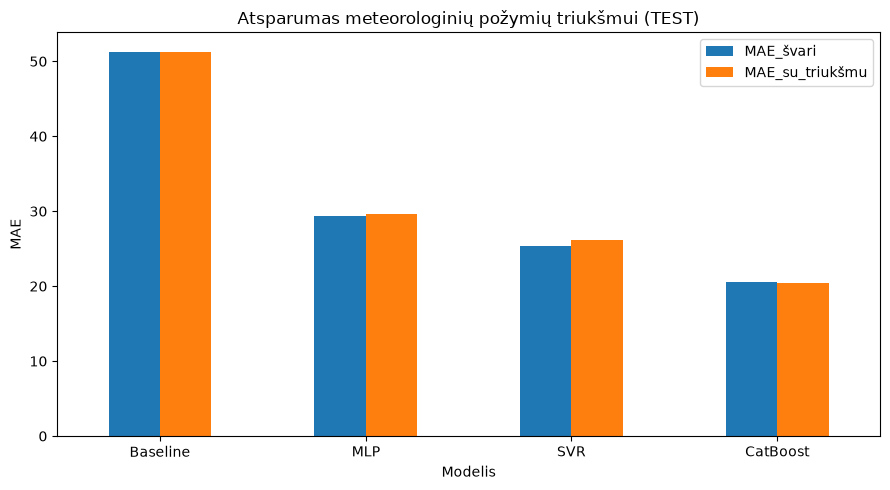

MAE pokytis pridėjus meteorologinių požymių triukšmą:
Baseline: 51.302 → 51.302 (+0.0%)
MLP: 29.387 → 29.563 (+0.6%)
SVR: 25.393 → 26.166 (+3.0%)
CatBoost: 20.523 → 20.365 (-0.8%)


In [23]:
# ATSPARUMO BANDYMAS: meteorologinių požymių triukšmas (TEST)

rng = np.random.RandomState(SEED)

X_test_clean = test[features].copy()
X_test_noisy = X_test_clean.copy()

weather_features = [
    c for c in ["temp", "atemp", "hum", "windspeed"]
    if c in X_test_noisy.columns
]

for c in weather_features:
    X_test_noisy[c] = (
        X_test_noisy[c] + rng.normal(0, 0.05, len(X_test_noisy))
    ).clip(0, 1)

y_test_rb = test["y"].to_numpy()
robust_rows = []

# Baseline nuo meteorologinių požymių nepriklauso
baseline_mae = mean_absolute_error(y_test_rb, test["baseline"])
robust_rows.append({
    "Modelis": "Baseline",
    "MAE_švari": baseline_mae,
    "MAE_su_triukšmu": baseline_mae
})

for name in ["MLP", "SVR", "CatBoost"]:
    model = fitted_models[name]

    pred_clean = np.maximum(0, model.predict(X_test_clean))
    pred_noisy = np.maximum(0, model.predict(X_test_noisy))

    robust_rows.append({
        "Modelis": name,
        "MAE_švari": mean_absolute_error(y_test_rb, pred_clean),
        "MAE_su_triukšmu": mean_absolute_error(y_test_rb, pred_noisy)
    })

robust_summary = pd.DataFrame(robust_rows).set_index("Modelis")
robust_summary["MAE_pokytis_%"] = (
    (robust_summary["MAE_su_triukšmu"] - robust_summary["MAE_švari"])
    / robust_summary["MAE_švari"] * 100
)

display(robust_summary.round(3))

ax = robust_summary[["MAE_švari", "MAE_su_triukšmu"]].plot(
    kind="bar", figsize=(9, 5), rot=0,
    title="Atsparumas meteorologinių požymių triukšmui (TEST)"
)
ax.set_ylabel("MAE")
ax.set_xlabel("Modelis")
plt.tight_layout()
plt.show()

print("MAE pokytis pridėjus meteorologinių požymių triukšmą:")
for name, row in robust_summary.iterrows():
    print(f"{name}: {row['MAE_švari']:.3f} → {row['MAE_su_triukšmu']:.3f} "
          f"({row['MAE_pokytis_%']:+.1f}%)")


## 10.

Galutinis rezultatų apibendrinimas

Ji remiasi **DEV rolling-origin** rezultatais, todėl galutinis TEST nėra naudojamas sprendžiant, kurį modelį laikyti pagrindiniu.


In [24]:
main_metric = "RMSE"
selected_model = cv_summary[main_metric].idxmin()

print("GALUTINĖ SANTRAUKA")
print("="*70)
print(f"Pagrindinė pasirinkimo metrika: {main_metric}.")
print(f"Pagal DEV rolling-origin mažiausią {main_metric} gavo {selected_model}: "
      f"{cv_summary.loc[selected_model, main_metric]:.3f}.")
print(f"Jo MAE: {cv_summary.loc[selected_model,'MAE']:.3f}.")
print(f"Jo piko neįvertinimo dažnis: "
      f"{cv_summary.loc[selected_model,'Peak_under_rate']:.3f}.")

print("\nPalyginimui su Baseline:")
for metric in ["MAE","RMSE","Peak_under_rate"]:
    model_v = cv_summary.loc[selected_model,metric]
    base_v = cv_summary.loc["Baseline",metric]
    direction = "mažesnė" if model_v < base_v else "didesnė"
    print(f"  {metric}: {selected_model} = {model_v:.3f}, "
          f"Baseline = {base_v:.3f} -> {direction} reikšmė.")

print(f'„Visi metodai buvo vertinami tomis pačiomis chronologinėmis rolling-origin sąlygomis. '
      f'Pagal iš anksto pasirinktą pagrindinę RMSE metriką DEV dalyje geriausią rezultatą gavo '
      f'{selected_model}. Galutinis TEST buvo naudojamas tik jau paruoštų modelių veikimui įvertinti.“')


GALUTINĖ SANTRAUKA
Pagrindinė pasirinkimo metrika: RMSE.
Pagal DEV rolling-origin mažiausią RMSE gavo CatBoost: 36.543.
Jo MAE: 24.341.
Jo piko neįvertinimo dažnis: 0.581.

Palyginimui su Baseline:
  MAE: CatBoost = 24.341, Baseline = 54.299 -> mažesnė reikšmė.
  RMSE: CatBoost = 36.543, Baseline = 87.825 -> mažesnė reikšmė.
  Peak_under_rate: CatBoost = 0.581, Baseline = 0.661 -> mažesnė reikšmė.
„Visi metodai buvo vertinami tomis pačiomis chronologinėmis rolling-origin sąlygomis. Pagal iš anksto pasirinktą pagrindinę RMSE metriką DEV dalyje geriausią rezultatą gavo CatBoost. Galutinis TEST buvo naudojamas tik jau paruoštų modelių veikimui įvertinti.“


- **MAE** – vidutinė absoliuti prognozės klaida nuomų skaičiumi.

Mažiau – geriau.

- **RMSE** – klaida, kuri stipriau baudžia didelius prašovimus.

Mažiau – geriau.

- **Piko neįvertinimo dažnis** – kokia dalis didelės paklausos valandų buvo prognozuota per mažai.

Mažiau – geriau.

- Pagrindinis metodų palyginimas atliekamas pagal **DEV rolling-origin** rezultatus.

TEST paliekamas galutiniam patikrinimui.
